# Predictive Modeling for Drug Classification

### Internship Project

**Objective**

Develop a Machine Learning model that predicts the appropriate drug for a patient based on medical attributes.

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/drug200.csv")

In [4]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [5]:
df.shape

(200, 6)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 12.5 KB


In [7]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [8]:
df.describe(include="object")

/var/folders/tz/dgcj8ssx3l5c1ycy_vfzhp2w0000gn/T/ipykernel_2383/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Sex,BP,Cholesterol,Drug
count,200,200,200,200
unique,2,3,2,5
top,M,HIGH,HIGH,DrugY
freq,104,77,103,91


In [9]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [10]:
df["Drug"].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

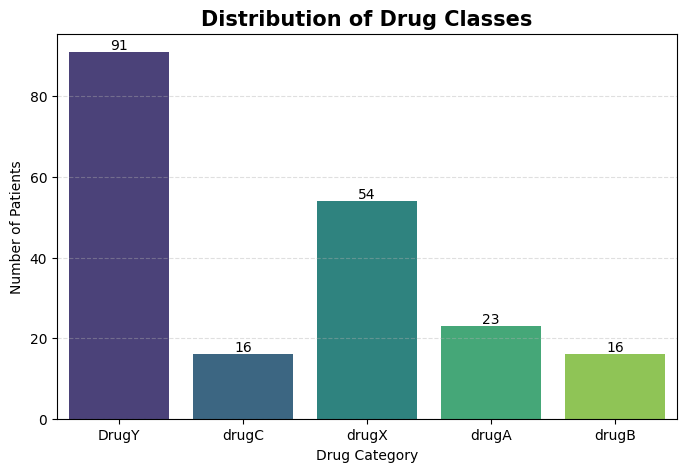

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Drug",
    data=df,
    hue="Drug",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Drug Classes", fontsize=15, fontweight="bold")
plt.xlabel("Drug Category")
plt.ylabel("Number of Patients")

for container in plt.gca().containers:
    plt.bar_label(container)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

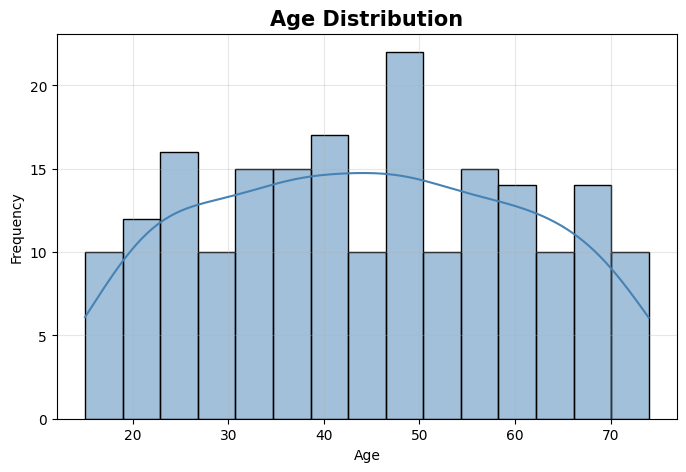

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Age Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

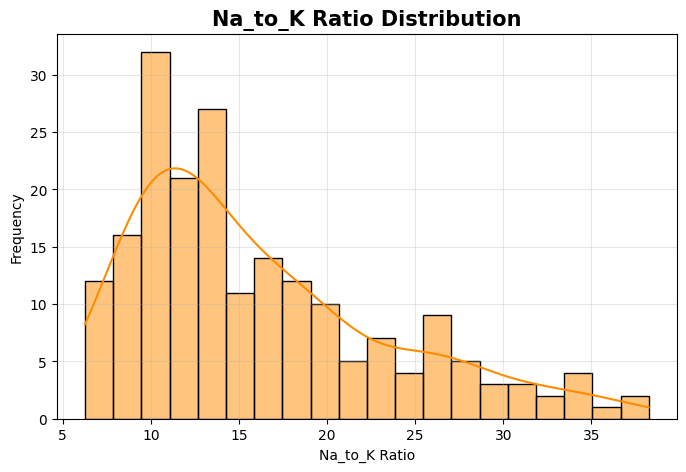

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Na_to_K"],
    bins=20,
    kde=True,
    color="darkorange"
)

plt.title("Na_to_K Ratio Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Na_to_K Ratio")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

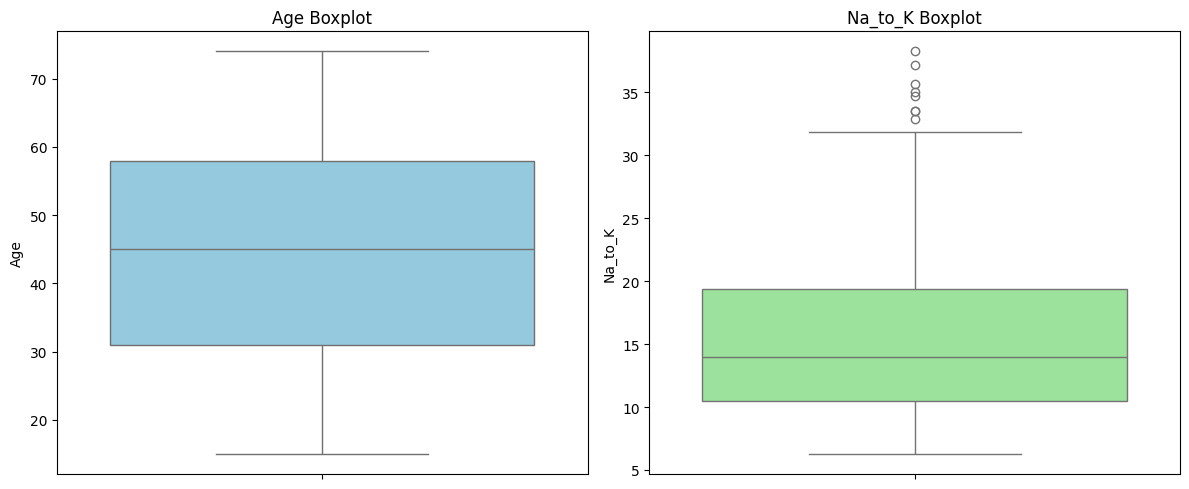

In [14]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(
    y=df["Age"],
    ax=ax[0],
    color="skyblue"
)

ax[0].set_title("Age Boxplot")

sns.boxplot(
    y=df["Na_to_K"],
    ax=ax[1],
    color="lightgreen"
)

ax[1].set_title("Na_to_K Boxplot")

plt.tight_layout()

plt.show()

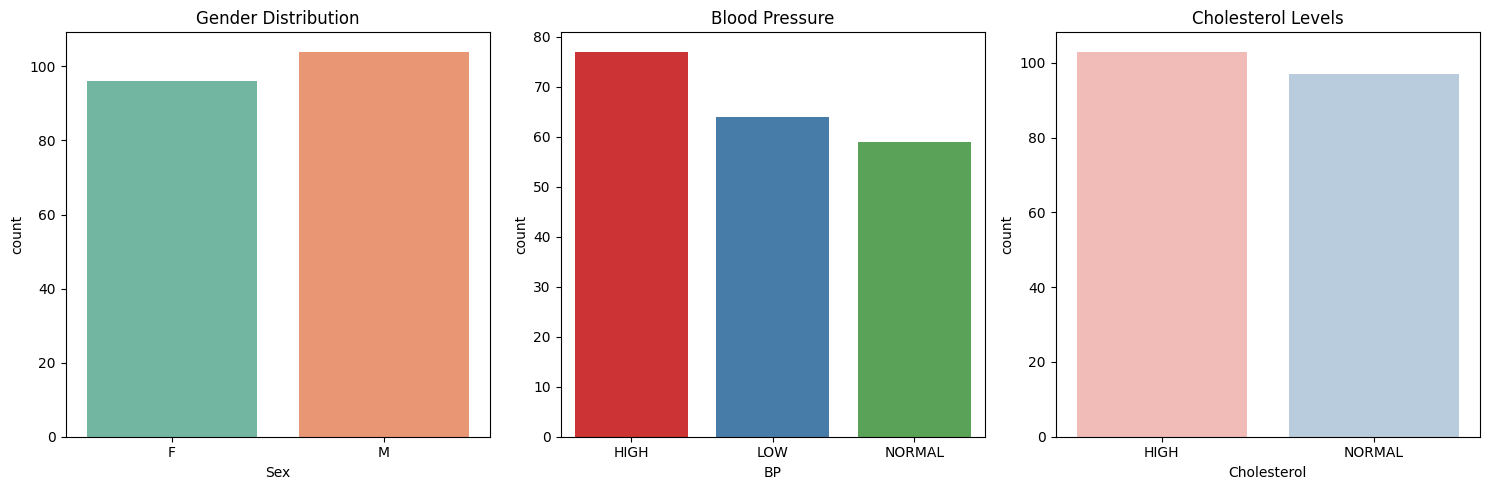

In [15]:
fig, ax = plt.subplots(1,3, figsize=(15,5))

sns.countplot(
    x="Sex",
    data=df,
    hue="Sex",
    palette="Set2",
    legend=False,
    ax=ax[0]
)

ax[0].set_title("Gender Distribution")

sns.countplot(
    x="BP",
    data=df,
    hue="BP",
    palette="Set1",
    legend=False,
    ax=ax[1]
)

ax[1].set_title("Blood Pressure")

sns.countplot(
    x="Cholesterol",
    data=df,
    hue="Cholesterol",
    palette="Pastel1",
    legend=False,
    ax=ax[2]
)

ax[2].set_title("Cholesterol Levels")

plt.tight_layout()

plt.show()

/var/folders/tz/dgcj8ssx3l5c1ycy_vfzhp2w0000gn/T/ipykernel_2383/38391968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


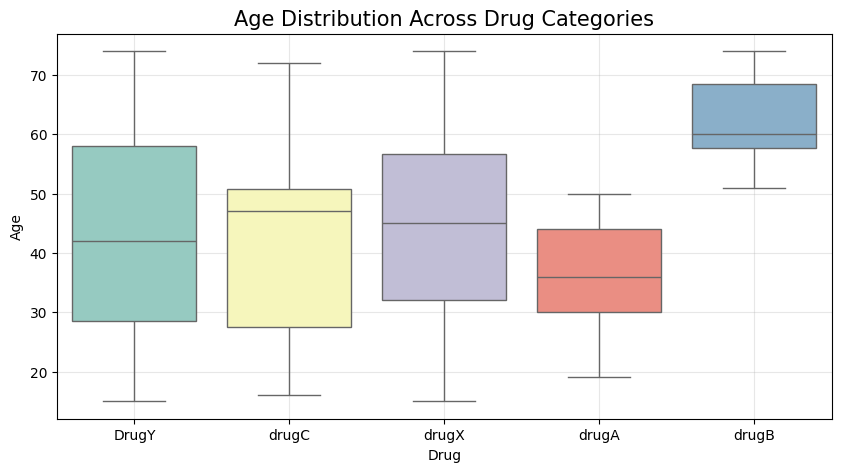

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Drug",
    y="Age",
    data=df,
    palette="Set3"
)

plt.title("Age Distribution Across Drug Categories", fontsize=15)

plt.grid(alpha=0.3)

plt.show()

/var/folders/tz/dgcj8ssx3l5c1ycy_vfzhp2w0000gn/T/ipykernel_2383/2937581712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


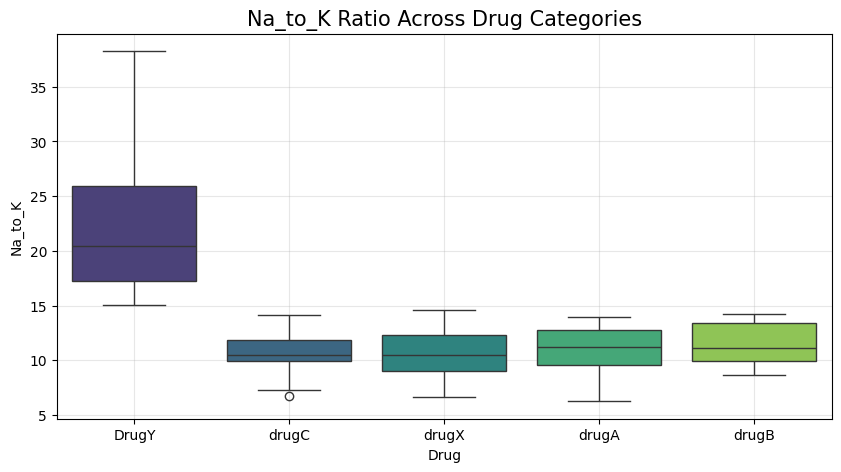

In [17]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Drug",
    y="Na_to_K",
    data=df,
    palette="viridis"
)

plt.title("Na_to_K Ratio Across Drug Categories", fontsize=15)

plt.grid(alpha=0.3)

plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Store encoders (useful later if needed)
label_encoders = {}

# Encode all categorical columns
categorical_columns = df_encoded.select_dtypes(include=['object']).columns

for column in categorical_columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])
    label_encoders[column] = le

# Display first few rows
df_encoded.head()

/var/folders/tz/dgcj8ssx3l5c1ycy_vfzhp2w0000gn/T/ipykernel_2383/3069210128.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_encoded.select_dtypes(include=['object']).columns


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [19]:
print(df_encoded.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB
None


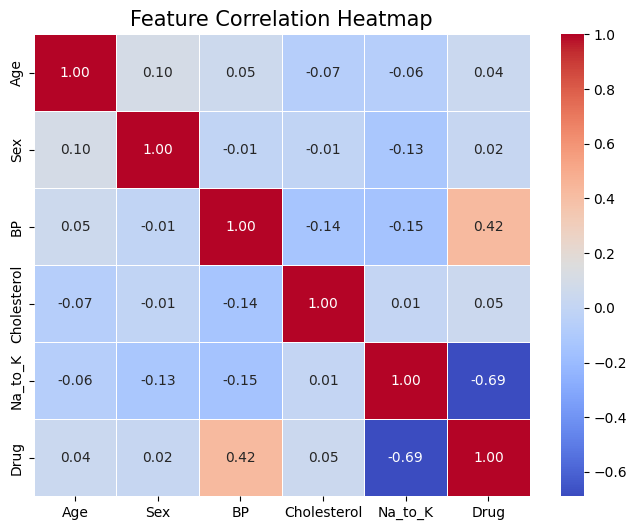

In [20]:
plt.figure(figsize=(8,6))

corr = df_encoded.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap", fontsize=15)

plt.show()

In [21]:
X = df_encoded.drop("Drug", axis=1)

y = df_encoded["Drug"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (200, 5)
Target Shape  : (200,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (160, 5)
Testing Data  : (40, 5)


In [23]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset
df_encoded = df.copy()

# Encode categorical columns
encoder = LabelEncoder()

df_encoded["Sex"] = encoder.fit_transform(df_encoded["Sex"])
df_encoded["BP"] = encoder.fit_transform(df_encoded["BP"])
df_encoded["Cholesterol"] = encoder.fit_transform(df_encoded["Cholesterol"])
df_encoded["Drug"] = encoder.fit_transform(df_encoded["Drug"])

print("Encoded Dataset:")
df_encoded.head()

Encoded Dataset:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0


In [26]:
# Separate features and target variable

X = df_encoded.drop("Drug", axis=1)

y = df_encoded["Drug"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (200, 5)
Target Shape   : (200,)


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (160, 5)
Testing Set  : (40, 5)


In [28]:
from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("✅ Decision Tree model trained successfully!")

✅ Decision Tree model trained successfully!


In [29]:
# Predict on the test dataset
y_pred_dt = dt_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_dt[:10])

First 10 Predictions:
[0 1 0 0 4 4 4 4 3 3]


In [30]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {accuracy:.2%}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 97.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



<Figure size 800x600 with 0 Axes>

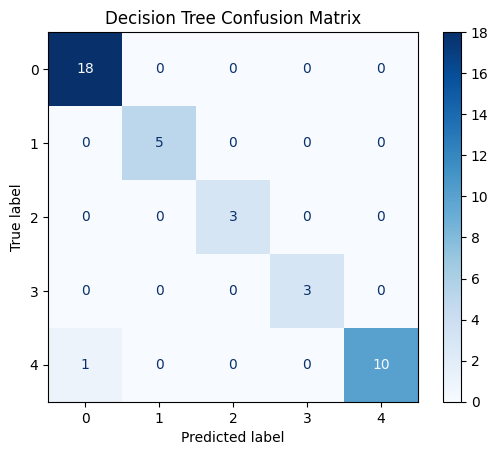

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [32]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [33]:
y_pred_rf = rf_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_rf[:10])

First 10 Predictions:
[0 1 0 0 4 4 4 4 3 3]


In [34]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 97.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



<Figure size 800x600 with 0 Axes>

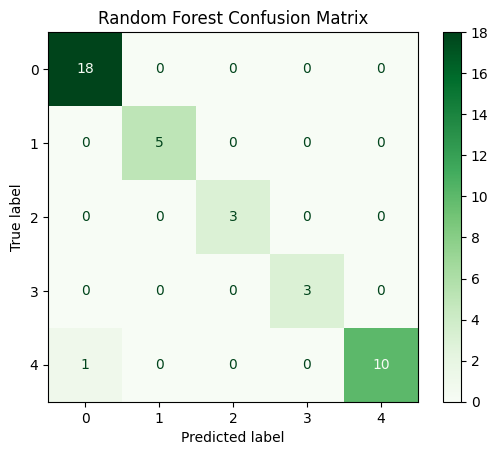

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.show()

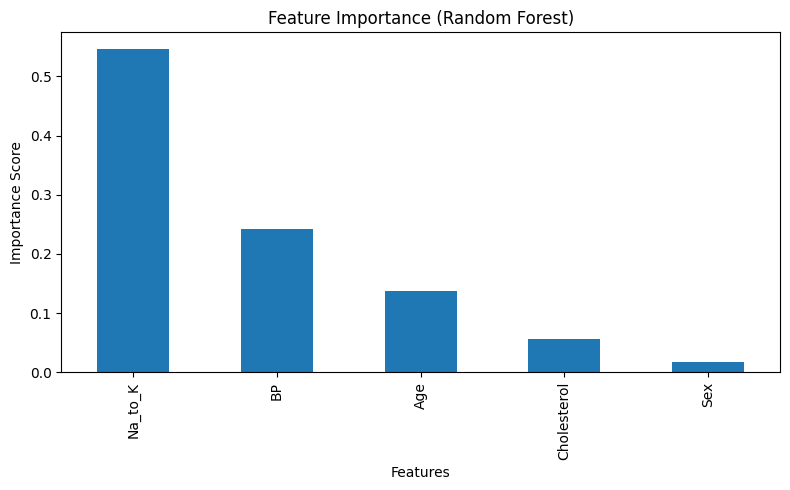

Na_to_K        0.546922
BP             0.241341
Age            0.137496
Cholesterol    0.056950
Sex            0.017291
dtype: float64


In [36]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.show()

print(feature_importance)

In [37]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
y_pred_lr = lr_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred_lr[:10])

First 10 Predictions:
[0 1 0 0 4 4 4 4 3 3]


In [39]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"Logistic Regression Accuracy: {lr_accuracy:.2%}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 97.50%

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



<Figure size 800x600 with 0 Axes>

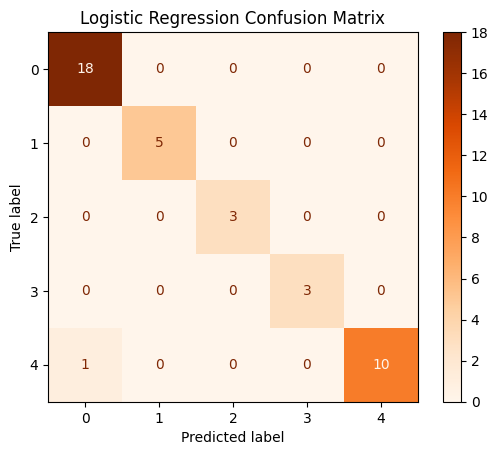

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    cmap="Oranges"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [41]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        lr_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"] * 100

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy
0,Decision Tree,97.5
1,Random Forest,97.5
2,Logistic Regression,97.5


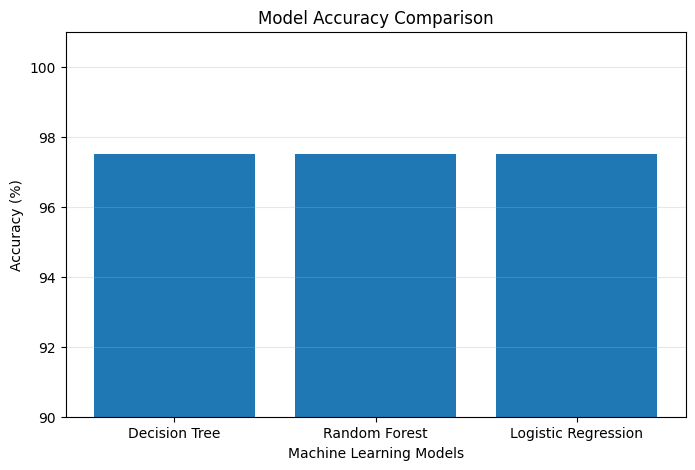

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy (%)")

plt.ylim(90,101)

plt.grid(axis="y",alpha=0.3)

plt.show()

In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores)

print()

print("Average Accuracy:", cv_scores.mean()*100)

Cross Validation Scores:
[1.    1.    1.    0.925 1.   ]

Average Accuracy: 98.5


In [44]:
import joblib

joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/random_forest_model.pkl'

In [45]:
import os
import joblib

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [46]:
!pip freeze > ../requirements.txt

print("✅ requirements.txt created successfully!")

✅ requirements.txt created successfully!


In [47]:
import os
os.listdir("..")

['requirements.txt',
 'images',
 'models',
 'README.md',
 '.gitignore',
 'venv',
 'notebook',
 '.git',
 'data',
 'data ']

In [48]:
import os
os.listdir("../models")

['random_forest_model.pkl']